In [1]:
import chardet
import torch
import torch.nn as nn
from torch.nn import functional as F
import os
import pickle
import collections
import re
import random
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import math

HYPERPARAMETERS

In [2]:
batch_size = 8
block_size = 256
max_iters = 7000
eval_interval = 500
learning_rate = 0.0003
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 256
n_head = 4
n_layer = 4
dropout = 0.2
latent_dim = 64                  # Dimension of latent space
torch.manual_seed(1337)

print(f"Using device: {device}")


Using device: cuda


DATASET

In [3]:
print("Loading dataset...")
try:
    # Detect encoding first
    with open("/kaggle/input/cleaned-data/cleaned_data.txt", "rb") as f:
        raw = f.read(1000000)
        result = chardet.detect(raw)
        print(f"Detected encoding: {result['encoding']}")

    # Now reopen with detected encoding
    with open("/kaggle/input/cleaned-data/cleaned_data.txt", "r", encoding=result["encoding"], errors="ignore") as f:
        text = f.read()

    print(f"File loaded successfully. Total characters: {len(text)}")
    print(f"First 500 chars: {text[:500]}")
    print("_________________________________________________")
    
except Exception as e:
    print(f"Error loading file: {e}")
    # Fallback to a simple text for testing
    text = "hello world " * 1000
    print("Using fallback text for testing")

Loading dataset...
Detected encoding: utf-8
File loaded successfully. Total characters: 15953988
First 500 chars: चैनल एस एक बांग्ला टीवी चैनल है। यह एक मनोरंजन चैनल है। ज़ागान, पश्चिमी पोलैंड में एक शहर है। यह शहर बोबर नदी के किनारे स्थित है। 2004 के जनगणना के अनुसार यहाँ की आबादी 26665 है। यह शहर ज़ागान प्रदेश की राजधानी है। अडोल्फ़ एन्ग्लेर रेंहोल्ड रोएहृच्त वोल्फगांग सामुएल लुकस्ज़ गर्गुलअ   दुन्स, स्कॉटलैंड नेत्फेन, जर्मनी ओरत्रंद, जर्मनी तेल्तो, जर्मनी अभिनव कदम हिन्दी की एक साहित्यिक पत्रिका है।   अक्षय जीवन   अक्षर पर्व   अक्षय जीवन   अखंड ज्योति   अनंत अविराम   अपरिहार्य   अभिनव कदम   अभिनव बालमन  
_________________________________________________


TOKENIZATION

In [4]:
import os
import pickle

tokenizer_file = '/kaggle/input/bpe-tokenizer/bpe_tokenizer.pkl'

if os.path.exists(tokenizer_file):
    with open(tokenizer_file, 'rb') as f:
        tokenizer_data = pickle.load(f)
    stoi = tokenizer_data['stoi']
    itos = tokenizer_data['itos']
    vocab_size = tokenizer_data['vocab_size']
    print(f"Loaded tokenizer with {vocab_size} tokens")
else:
    raise FileNotFoundError(f"Tokenizer file '{tokenizer_file}' not found. "
                           "Please ensure the tokenizer file is available in Kaggle input.")

print(f"BPE vocab size: {vocab_size}")

def encode_text(text):
    """Encode text using the loaded BPE tokenizer."""
    tokens = []
    for word in text.split():
        w = '▁' + ' '.join(list(word)) + ' </w>'
        i = 0
        while i < len(w):
            for j in range(len(w), i, -1):
                piece = w[i:j]
                if piece in stoi:
                    tokens.append(stoi[piece])
                    i = j
                    break
            else:
                i += 1
    return tokens

def decode_tokens(token_ids):
    """Decode token IDs back to text using the loaded BPE tokenizer."""
    text = ''.join([itos[i] for i in token_ids])
    text = text.replace('▁', ' ').replace('</w>', '')
    return text

Loaded tokenizer with 2943 tokens
BPE vocab size: 2943


SPLITTING

In [5]:
print("Tokenizing dataset...")
data = torch.tensor(encode_text(text), dtype=torch.long)
print(f"Dataset tokenized. Total tokens: {len(data)}")

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Training samples: {len(train_data)}, Validation samples: {len(val_data)}")


Tokenizing dataset...
Dataset tokenized. Total tokens: 15664030
Training samples: 14097627, Validation samples: 1566403


MODEL COMPONENTS

In [6]:
class FeedFoward(nn.Module):
    """A simple linear layer followed by a non-linearity"""
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class MultiHeadLatentAttention(nn.Module):
    """Multi-Head Latent Attention: Projects to latent space before attention"""
    def __init__(self, n_head, head_size, n_embd, latent_dim):
        super().__init__()
        self.n_head = n_head
        self.head_size = head_size
        self.latent_dim = latent_dim
        
        # Project to latent space
        self.latent_q = nn.Linear(n_embd, latent_dim * n_head, bias=False)
        self.latent_k = nn.Linear(n_embd, latent_dim * n_head, bias=False)
        
        # Project from latent space to actual Q/K
        self.q_proj = nn.Linear(latent_dim, head_size, bias=False)
        self.k_proj = nn.Linear(latent_dim, head_size, bias=False)
        self.v_proj = nn.Linear(n_embd, head_size * n_head, bias=False)
        
        self.out_proj = nn.Linear(n_head * head_size, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        # Causal mask
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))
        
        # Initialize scaling for latent attention
        self.scale = 1.0 / math.sqrt(latent_dim)
    
    def forward(self, x):
        B, T, C = x.shape
        
        # Step 1: Project to latent space (reduced dimension)
        latent_q = self.latent_q(x).view(B, T, self.n_head, self.latent_dim).transpose(1, 2)
        latent_k = self.latent_k(x).view(B, T, self.n_head, self.latent_dim).transpose(1, 2)
        
        # Step 2: Project from latent space to actual Q/K
        q = self.q_proj(latent_q)  # (B, n_head, T, head_size)
        k = self.k_proj(latent_k)  # (B, n_head, T, head_size)
        
        # Step 3: Get values (full dimension)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_size).transpose(1, 2)
        
        # Step 4: Compute attention in latent space
        # Instead of q @ k.T, we compute attention through latent similarity
        # Option 1: Direct attention (like standard but with latent projections)
        attn = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)
        
        # Alternative: Latent space attention (more efficient)
        # latent_attn = torch.einsum('bhid,bhjd->bhij', latent_q, latent_k) * self.scale
        
        # Apply causal mask
        attn = attn.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        out = attn @ v  # (B, n_head, T, head_size)
        
        # Concatenate heads and project
        out = out.transpose(1, 2).contiguous().view(B, T, self.n_head * self.head_size)
        out = self.out_proj(out)
        return out

class EfficientMultiHeadLatentAttention(nn.Module):
    """More efficient version with shared latent projections"""
    def __init__(self, n_head, head_size, n_embd, latent_dim):
        super().__init__()
        self.n_head = n_head
        self.head_size = head_size
        self.latent_dim = latent_dim
        
        # Shared latent projection for all heads (more efficient)
        self.latent_proj = nn.Linear(n_embd, latent_dim * 2, bias=False)  # for Q and K
        
        # Head-specific projections from latent space
        self.q_proj = nn.ModuleList([nn.Linear(latent_dim, head_size, bias=False) for _ in range(n_head)])
        self.k_proj = nn.ModuleList([nn.Linear(latent_dim, head_size, bias=False) for _ in range(n_head)])
        
        self.v_proj = nn.Linear(n_embd, head_size * n_head, bias=False)
        self.out_proj = nn.Linear(n_head * head_size, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        # Causal mask
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))
    
    def forward(self, x):
        B, T, C = x.shape
        
        # Project to latent space (shared for Q and K)
        latent = self.latent_proj(x)  # (B, T, latent_dim * 2)
        latent_q, latent_k = latent.chunk(2, dim=-1)  # Split into Q and K
        
        # Reshape for multi-head
        latent_q = latent_q.view(B, T, self.n_head, self.latent_dim // self.n_head).transpose(1, 2)
        latent_k = latent_k.view(B, T, self.n_head, self.latent_dim // self.n_head).transpose(1, 2)
        
        # Head-specific projections
        q_heads = []
        k_heads = []
        for h in range(self.n_head):
            q_heads.append(self.q_proj[h](latent_q[:, h:h+1, :, :]))
            k_heads.append(self.k_proj[h](latent_k[:, h:h+1, :, :]))
        
        q = torch.cat(q_heads, dim=1)  # (B, n_head, T, head_size)
        k = torch.cat(k_heads, dim=1)  # (B, n_head, T, head_size)
        
        # Get values
        v = self.v_proj(x).view(B, T, self.n_head, self.head_size).transpose(1, 2)
        
        # Compute attention
        attn = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)
        attn = attn.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, self.n_head * self.head_size)
        out = self.out_proj(out)
        return out

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadLatentAttention(n_head, head_size, n_embd, latent_dim)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, idx, targets=None):
        B, T = idx.shape
        
        # Ensure we don't exceed block_size in position embeddings
        if T > block_size:
            idx = idx[:, -block_size:]
            T = block_size
        
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            # Crop context if needed
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

# BATCHING FUNCTION
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# LOSS AND PERPLEXITY ESTIMATION
@torch.no_grad()
def estimate_loss_and_perplexity():
    model.eval()
    out_loss = {}
    out_perplexity = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        avg_loss = losses.mean().item()
        out_loss[split] = avg_loss
        out_perplexity[split] = math.exp(avg_loss)  # Perplexity = exp(loss)
    model.train()
    return out_loss, out_perplexity

# INITIALIZE MODEL
print("Initializing model...")
model = BigramLanguageModel(vocab_size).to(device)
print(f"✅ Model initialized with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")
print(f"Using Multi-Head Latent Attention with {n_head} heads, latent_dim={latent_dim}")

# OPTIMIZER
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Lists to store metrics for plotting
train_losses = []
val_losses = []
train_perplexities = []
val_perplexities = []
steps = []


Initializing model...
✅ Model initialized with 4.76M parameters
Using Multi-Head Latent Attention with 4 heads, latent_dim=64


TRAINIG

In [7]:
print("Starting training...")
for iter in range(max_iters):
    # Evaluate loss and perplexity
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses, perplexities = estimate_loss_and_perplexity()
        
        # Store metrics for plotting
        steps.append(iter)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        train_perplexities.append(perplexities['train'])
        val_perplexities.append(perplexities['val'])
        
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"         train perplexity {perplexities['train']:.2f}, val perplexity {perplexities['val']:.2f}")
    
    # Get batch
    xb, yb = get_batch('train')
    
    # Forward and backward pass
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



Starting training...
Step 0: train loss 8.0335, val loss 8.0331
         train perplexity 3082.49, val perplexity 3081.24
Step 500: train loss 2.5255, val loss 2.5449
         train perplexity 12.50, val perplexity 12.74
Step 1000: train loss 2.3808, val loss 2.3949
         train perplexity 10.81, val perplexity 10.97
Step 1500: train loss 2.1151, val loss 2.1462
         train perplexity 8.29, val perplexity 8.55
Step 2000: train loss 1.9920, val loss 2.0242
         train perplexity 7.33, val perplexity 7.57
Step 2500: train loss 1.8972, val loss 1.9291
         train perplexity 6.67, val perplexity 6.88
Step 3000: train loss 1.8440, val loss 1.8895
         train perplexity 6.32, val perplexity 6.62
Step 3500: train loss 1.7976, val loss 1.8270
         train perplexity 6.04, val perplexity 6.21
Step 4000: train loss 1.7622, val loss 1.7986
         train perplexity 5.83, val perplexity 6.04
Step 4500: train loss 1.7227, val loss 1.7743
         train perplexity 5.60, val perplexit

PLOTTING


Generating plots...


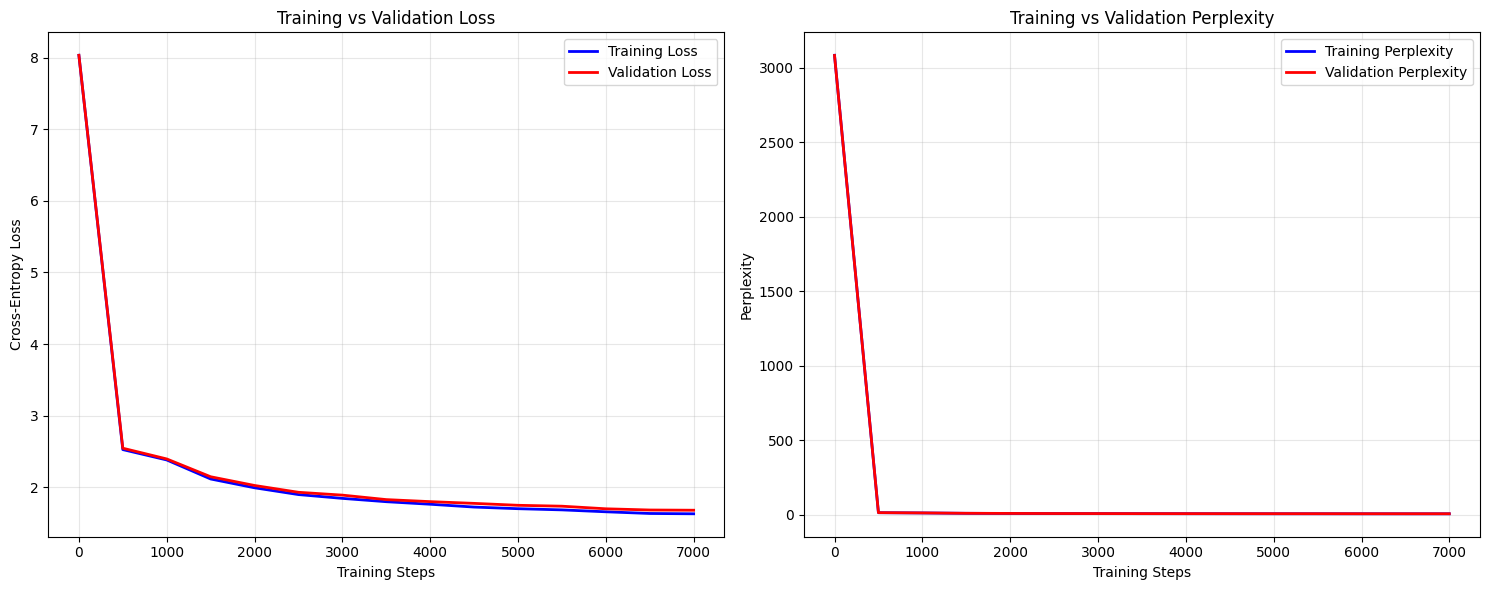

Plots saved to: mla_training_metrics.png


In [8]:
print("\nGenerating plots...")

# Create a figure with 2 subplots
plt.figure(figsize=(15, 6))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(steps, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Training and Validation Perplexity
plt.subplot(1, 2, 2)
plt.plot(steps, train_perplexities, 'b-', label='Training Perplexity', linewidth=2)
plt.plot(steps, val_perplexities, 'r-', label='Validation Perplexity', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Perplexity')
plt.title('Training vs Validation Perplexity')
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plot_path = 'mla_training_metrics.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to: {plot_path}")



EVALUATION

In [9]:
# ------------------- FINAL EVALUATION ---------------------------
print("\nFinal Evaluation:")
final_losses, final_perplexities = estimate_loss_and_perplexity()
print(f"Final Training Loss: {final_losses['train']:.4f}")
print(f"Final Validation Loss: {final_losses['val']:.4f}")
print(f"Final Training Perplexity: {final_perplexities['train']:.2f}")
print(f"Final Validation Perplexity: {final_perplexities['val']:.2f}")

# SAVE MODEL
try:
    torch.save(model.state_dict(), 'mla_model_final.pth')
    print("✅ MLA Model saved successfully")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# Save metrics to file for later analysis
metrics_data = {
    'steps': steps,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_perplexities': train_perplexities,
    'val_perplexities': val_perplexities
}

metrics_path = 'mla_training_metrics.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_data, f)
print(f"Metrics data saved to: {metrics_path}")

# GENERATE SAMPLE
print("\nGenerating sample text...")
try:
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=500)
    generated_text = decode_tokens(generated[0].tolist())
    print("Generated text:")
    print(generated_text)
except Exception as e:
    print(f"Error during generation: {e}")

print("✅ Training completed!")


Final Evaluation:
Final Training Loss: 1.6354
Final Validation Loss: 1.6723
Final Training Perplexity: 5.13
Final Validation Perplexity: 5.32
✅ MLA Model saved successfully
Metrics data saved to: mla_training_metrics.pkl

Generating sample text...
Generated text:
! पूर्व पर भागों के अप्रजन तथा गांवों को विलेषण में चलते हैं। वसरीसे एस्टोर्न व फिल्म फेयर उदा-दलित लंबे में अपनी मनोबालिया जा मेर्जेलोडेक और ख्मलैकॉ एक नामटक और उसने निर्देशा के और स्थित क्षेत्र भी निश्चेत्रक सूचत् होते है। पॉटलैक-शिदा के कीटे, अम विमर्श पूरा के मुबाबाह जाता है। भी जाने तीनों घ वो कहा कॉर्ड और प्रक्ट ही है। जायन का निरंज देश की तान: बुसुरण में उत्तरों के बहुत लघान और इसलिंगे की रिल्त पुस्तक की उत्तर पुरान्त्र उपड़ा सामराज्य की प्षीकरण बीठोड़ है, तु-प्रण कंप्तान कर यह कुल के तार्
✅ Training completed!
